**Imports, Drive mount, and paths**

In [1]:
import os
import json
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from tensorflow.keras import mixed_precision

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

sns.set(style="whitegrid", context="notebook")

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision enabled. GPU will be leveraged.')

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision enabled. GPU will be leveraged.


In [3]:
import random
import numpy as np
import pandas as pd

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Paths and constants**

In [5]:
# Base project directory
BASE_DIR = "/content/drive/MyDrive/Cross-Dataset Generalization Thesis"

EUROSAT_DIR = os.path.join(BASE_DIR, "eurosat")
UCM_DIR     = os.path.join(BASE_DIR, "uc_merced")

# Day-3 few-shot output directories (top-level, not under cross_dataset_zero_shot)
FEWSHOT_DIR      = os.path.join(BASE_DIR, "few_shot")
FEWSHOT_METRICS  = os.path.join(FEWSHOT_DIR, "metrics")
FEWSHOT_NPY      = os.path.join(FEWSHOT_DIR, "npy")
FEWSHOT_FIGS     = os.path.join(FEWSHOT_DIR, "figs")
FEWSHOT_HISTORY  = os.path.join(FEWSHOT_DIR, "history")

for d in [FEWSHOT_DIR, FEWSHOT_METRICS, FEWSHOT_NPY, FEWSHOT_FIGS, FEWSHOT_HISTORY]:
    os.makedirs(d, exist_ok=True)

print("FEWSHOT_DIR:", FEWSHOT_DIR)
print("Subdirs:", os.listdir(FEWSHOT_DIR))

FEWSHOT_DIR: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/few_shot
Subdirs: ['metrics', 'npy', 'figs', 'history']


UC Merced loading + 60/20/20 split (unbatched, then batched once)
**bold text**

In [6]:
import tensorflow_datasets as tfds

IMG_SIZE   = (128, 128)
BATCH_SIZE = 64

def preprocess_image(example):
    image = tf.image.resize(example["image"], IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = example["label"]
    return image, label

builder = tfds.builder("uc_merced")
builder.download_and_prepare()

# Full split, preprocessed
full_ds = builder.as_dataset(split="train", shuffle_files=False)
full_ds = full_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

num_total = builder.info.splits["train"].num_examples
print("Total images:", num_total)

train_size = int(0.6 * num_total)
val_size   = int(0.2 * num_total)
test_size  = num_total - train_size - val_size

full_ds = full_ds.shuffle(num_total, seed=42, reshuffle_each_iteration=False)

ucm_train_raw = full_ds.take(train_size)
ucm_val_raw   = full_ds.skip(train_size).take(val_size)
ucm_test_raw  = full_ds.skip(train_size + val_size)

ucm_train_raw = ucm_train_raw.cache()
ucm_val_raw   = ucm_val_raw.cache()
ucm_test_raw  = ucm_test_raw.cache()

num_classes_ucm = builder.info.features["label"].num_classes
class_names_ucm = builder.info.features["label"].names

print("Classes:", num_classes_ucm, "Train/Val/Test:", train_size, val_size, test_size)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/uc_merced/incomplete.HBRPOI_2.0.0/uc_merced-train.tfrecord*...:   0%|     …

Dataset uc_merced downloaded and prepared to /root/tensorflow_datasets/uc_merced/2.0.0. Subsequent calls will reuse this data.
Total images: 2100
Classes: 21 Train/Val/Test: 1260 420 420


**Build NumPy arrays for few‑shot sampling (from unbatched ucm_train_raw)**

In [7]:
# Convert preprocessed training set (UNBATCHED) to NumPy
train_images = []
train_labels = []

for img, lab in ucm_train_raw:
    train_images.append(img.numpy())   # (128, 128, 3)
    train_labels.append(lab.numpy())   # scalar

train_images = np.stack(train_images, axis=0)
train_labels = np.array(train_labels)

print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)

# Indices per class for k-shot sampling
indices_per_class = {c: [] for c in range(num_classes_ucm)}
for idx, lab in enumerate(train_labels):
    indices_per_class[int(lab)].append(idx)

{k: len(v) for k, v in indices_per_class.items()}

Train images shape: (1260, 128, 128, 3)
Train labels shape: (1260,)


{0: 60,
 1: 53,
 2: 57,
 3: 65,
 4: 54,
 5: 64,
 6: 61,
 7: 62,
 8: 55,
 9: 65,
 10: 49,
 11: 62,
 12: 59,
 13: 63,
 14: 64,
 15: 61,
 16: 57,
 17: 58,
 18: 60,
 19: 63,
 20: 68}

** Create batched datasets once, for training/eval**

In [8]:
# Now batch ONCE for use by Keras
ucm_train_ds = ucm_train_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ucm_val_ds   = ucm_val_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ucm_test_ds  = ucm_test_raw.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Sanity check
for x_batch, y_batch in ucm_test_ds.take(1):
    print("Test batch shape:", x_batch.shape, y_batch.shape)

Test batch shape: (64, 128, 128, 3) (64,)


**Few‑shot helpers (unchanged, but use the NumPy arrays)**

In [9]:
K_VALUES = [5, 10, 20]

def make_fewshot_dataset(k, val_per_class=0):
    train_idx = []
    val_idx = []

    for c in range(num_classes_ucm):
        all_idx = indices_per_class[c].copy()
        random.shuffle(all_idx)

        k_total = k + val_per_class
        if len(all_idx) < k_total:
            k_total = len(all_idx)

        selected = all_idx[:k_total]
        if val_per_class > 0:
            val_idx.extend(selected[:val_per_class])
            train_idx.extend(selected[val_per_class:])
        else:
            train_idx.extend(selected)

    train_idx = np.array(train_idx)
    val_idx   = np.array(val_idx) if val_per_class > 0 else None

    x_train = train_images[train_idx]
    y_train = train_labels[train_idx]

    if val_per_class > 0 and len(val_idx) > 0:
        x_val = train_images[val_idx]
        y_val = train_labels[val_idx]
    else:
        x_val, y_val = None, None

    print(f"k={k}: train {x_train.shape[0]} samples, val {0 if x_val is None else x_val.shape[0]} samples")
    return (x_train, y_train), (x_val, y_val)

def to_tf_dataset(x, y, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(y), reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

**Evaluation over test set (uses ucm_test_ds directly, no extra batching)**

In [10]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def reset_head_weights(model):
    last_dense = model.get_layer("ucm_head")
    for var in last_dense.weights:
        var.assign(tf.random.normal(shape=var.shape, stddev=0.01))

def evaluate_on_test(model, dataset):
    all_y_true = []
    all_y_pred = []

    for x_batch, y_batch in dataset:   # dataset is already batched once
        logits = model.predict(x_batch, verbose=0)
        preds = np.argmax(logits, axis=1)
        all_y_true.append(y_batch.numpy())
        all_y_pred.append(preds)

    y_true = np.concatenate(all_y_true, axis=0)
    y_pred = np.concatenate(all_y_pred, axis=0)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes_ucm))

    return y_true, y_pred, acc, macro_f1, cm

def plot_confusion_matrix(cm, labels, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, cmap="Blues",
                xticklabels=labels, yticklabels=labels,
                fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()


**Load EuroSAT ResNet50 source model**

In [11]:
from tensorflow.keras import models, layers, optimizers, losses, metrics

EUROSAT_MODEL_PATH = os.path.join(
    EUROSAT_DIR, "models", "eurosat_resnet50_full.keras"
)

base_model = tf.keras.models.load_model(EUROSAT_MODEL_PATH)
base_model.summary()

Model: "resnet50_eurosat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,238,244 (275.57 MB)

 Trainable params: 24,061,706 (91.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

 Optimizer params: 48,123,418 (183.58 MB)

**Build a target‑adapted model (UC Merced classes):**

In [12]:
from tensorflow.keras import models, layers, optimizers, losses, metrics

# feature extractor from loaded EuroSAT model (penultimate layer)
feature_extractor = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model.layers[-2].output  # adjust if your last Dense is not at -1
)

# Freeze backbone
for layer in feature_extractor.layers:
    layer.trainable = False

# Optionally unfreeze last N layers
N_UNFREEZE = 10
for layer in feature_extractor.layers[-N_UNFREEZE:]:
    layer.trainable = True

inputs = feature_extractor.input
x = feature_extractor(inputs, training=False)
outputs = layers.Dense(num_classes_ucm, activation="softmax", name="ucm_head")(x)

fewshot_model = tf.keras.Model(inputs=inputs, outputs=outputs)

fewshot_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy(name="accuracy")],
)

fewshot_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 256)            │    24,112,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ucm_head (Dense)                │ (None, 21)             │         5,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,117,653 (92.00 MB)

 Trainable params: 24,064,533 (91.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

**Run few‑shot experiments and save outputs**

In [13]:
MODEL_NAME = "resnet50"
SRC_TO_TGT = "eurosat_to_ucm"
VAL_PER_CLASS = 1
EPOCHS = 8

results = []

for k in K_VALUES:
    print(f"\n===== Few-shot {SRC_TO_TGT}, k={k} =====")
    (x_train, y_train), (x_val, y_val) = make_fewshot_dataset(
        k, val_per_class=VAL_PER_CLASS
    )

    train_ds = to_tf_dataset(x_train, y_train, shuffle=True)
    if x_val is not None:
        val_ds = to_tf_dataset(x_val, y_val, shuffle=False)
    else:
        val_ds = None

    # Re‑initialize classification head for this k
    reset_head_weights(fewshot_model)

    if val_ds is not None:
        history = fewshot_model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            verbose=1,
        )
    else:
        history = fewshot_model.fit(
            train_ds,
            epochs=EPOCHS,
            verbose=1,
        )

    # Evaluate on full UC Merced test set
    y_true, y_pred, acc, macro_f1, cm = evaluate_on_test(fewshot_model, ucm_test_ds)

    # ---- save metrics ----
    metrics_dict = {
        "source_dataset": "EuroSAT",
        "target_dataset": "UC Merced",
        "model": MODEL_NAME,
        "k_shot_per_class": int(k),
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
    }

    metrics_path = os.path.join(
        FEWSHOT_METRICS,
        f"fewshot_{SRC_TO_TGT}_{MODEL_NAME}_k{k}_metrics.json",
    )
    with open(metrics_path, "w") as f:
        json.dump(metrics_dict, f, indent=2)

    # ---- save y_true / y_pred ----
    y_true_path = os.path.join(
        FEWSHOT_NPY,
        f"fewshot_{SRC_TO_TGT}_{MODEL_NAME}_k{k}_y_true.npy",
    )
    y_pred_path = os.path.join(
        FEWSHOT_NPY,
        f"fewshot_{SRC_TO_TGT}_{MODEL_NAME}_k{k}_y_pred.npy",
    )
    np.save(y_true_path, y_true)
    np.save(y_pred_path, y_pred)

    # ---- save training history as CSV ----
    history_df = pd.DataFrame(history.history)
    history_path = os.path.join(
        FEWSHOT_HISTORY,
        f"fewshot_{SRC_TO_TGT}_{MODEL_NAME}_k{k}_history.csv",
    )
    history_df.to_csv(history_path, index=False)

    # ---- save confusion matrix figure ----
    title = f"Few-shot {SRC_TO_TGT} {MODEL_NAME} k={k}"
    plot_confusion_matrix(cm, class_names_ucm, title)
    fig_path = os.path.join(
        FEWSHOT_FIGS,
        f"fewshot_{SRC_TO_TGT}_{MODEL_NAME}_k{k}_confusion_matrix.png",
    )
    plt.savefig(fig_path, dpi=150)
    plt.close()

    # ---- store summary for table in this notebook ----
    results.append(
        {
            "k": k,
            "accuracy": acc,
            "macro_f1": macro_f1,
            "metrics_path": metrics_path,
        }
    )

results


===== Few-shot eurosat_to_ucm, k=5 =====
k=5: train 105 samples, val 21 samples
Epoch 1/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 143s 55s/step - accuracy: 0.0358 - loss: 3.0446 - val_accuracy: 0.0476 - val_loss: 3.3643
Epoch 2/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.2443 - loss: 2.7986 - val_accuracy: 0.0476 - val_loss: 3.1400
Epoch 3/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5222 - loss: 2.5783 - val_accuracy: 0.0476 - val_loss: 3.0989
Epoch 4/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.7273 - loss: 2.2699 - val_accuracy: 0.0476 - val_loss: 3.0976
Epoch 5/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8157 - loss: 1.9849 - val_accuracy: 0.0476 - val_loss: 3.1111
Epoch 6/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9105 - loss: 1.8021 - val_accuracy: 0.0476 - val_loss: 3.1247
Epoch 7/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9757 - loss: 1.5142 - val_accuracy: 0.0476 - val_loss: 3.1418
Epoch 8/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step 

[{'k': 5,
  'accuracy': 0.047619047619047616,
  'macro_f1': 0.004329004329004329,
  'metrics_path': '/content/drive/MyDrive/Cross-Dataset Generalization Thesis/few_shot/metrics/fewshot_eurosat_to_ucm_resnet50_k5_metrics.json'},
 {'k': 10,
  'accuracy': 0.047619047619047616,
  'macro_f1': 0.004329004329004329,
  'metrics_path': '/content/drive/MyDrive/Cross-Dataset Generalization Thesis/few_shot/metrics/fewshot_eurosat_to_ucm_resnet50_k10_metrics.json'},
 {'k': 20,
  'accuracy': 0.047619047619047616,
  'macro_f1': 0.004329004329004329,
  'metrics_path': '/content/drive/MyDrive/Cross-Dataset Generalization Thesis/few_shot/metrics/fewshot_eurosat_to_ucm_resnet50_k20_metrics.json'}]

**Build Day‑3 “performance vs shots” table for this direction**

In [14]:
rows = []
for r in results:
    rows.append(
        {
            "Source → Target": "EuroSAT → UCM",
            "Model": "ResNet50",
            "Shots per class (k)": r["k"],
            "Target accuracy": r["accuracy"],
            "Target macro-F1": r["macro_f1"],
        }
    )

df_fewshot_e2u = pd.DataFrame(rows)
df_fewshot_e2u

,Source → Target,Model,Shots per class (k),Target accuracy,Target macro-F1
0,EuroSAT → UCM,ResNet50,5,0.047619,0.004329
1,EuroSAT → UCM,ResNet50,10,0.047619,0.004329
2,EuroSAT → UCM,ResNet50,20,0.047619,0.004329


In [15]:
fewshot_table_path = os.path.join(
    FEWSHOT_DIR, "day3_fewshot_eurosat_to_ucm_resnet50.csv"
)
df_fewshot_e2u.to_csv(fewshot_table_path, index=False)
print("Saved Day-3 EuroSAT→UCM few-shot table to:", fewshot_table_path)

Saved Day-3 EuroSAT→UCM few-shot table to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/few_shot/day3_fewshot_eurosat_to_ucm_resnet50.csv


In [16]:
cm_dict = {}

for k in K_VALUES:
    print(f"\nRe-evaluating for k={k} to get confusion matrix")

    (x_train, y_train), (x_val, y_val) = make_fewshot_dataset(
        k, val_per_class=VAL_PER_CLASS
    )

    train_ds = to_tf_dataset(x_train, y_train, shuffle=True)
    val_ds = to_tf_dataset(x_val, y_val, shuffle=False) if x_val is not None else None

    reset_head_weights(fewshot_model)

    if val_ds is not None:
        fewshot_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=0)
    else:
        fewshot_model.fit(train_ds, epochs=EPOCHS, verbose=0)

    _, _, _, _, cm = evaluate_on_test(fewshot_model, ucm_test_ds)
    cm_dict[k] = cm



Re-evaluating for k=5 to get confusion matrix
k=5: train 105 samples, val 21 samples

Re-evaluating for k=10 to get confusion matrix
k=10: train 210 samples, val 21 samples

Re-evaluating for k=20 to get confusion matrix
k=20: train 420 samples, val 21 samples


In [19]:
def show_cm(cm, labels, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, cmap="Blues",
                xticklabels=labels, yticklabels=labels, fmt="d",
                linewidths=0.5, linecolor='black')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

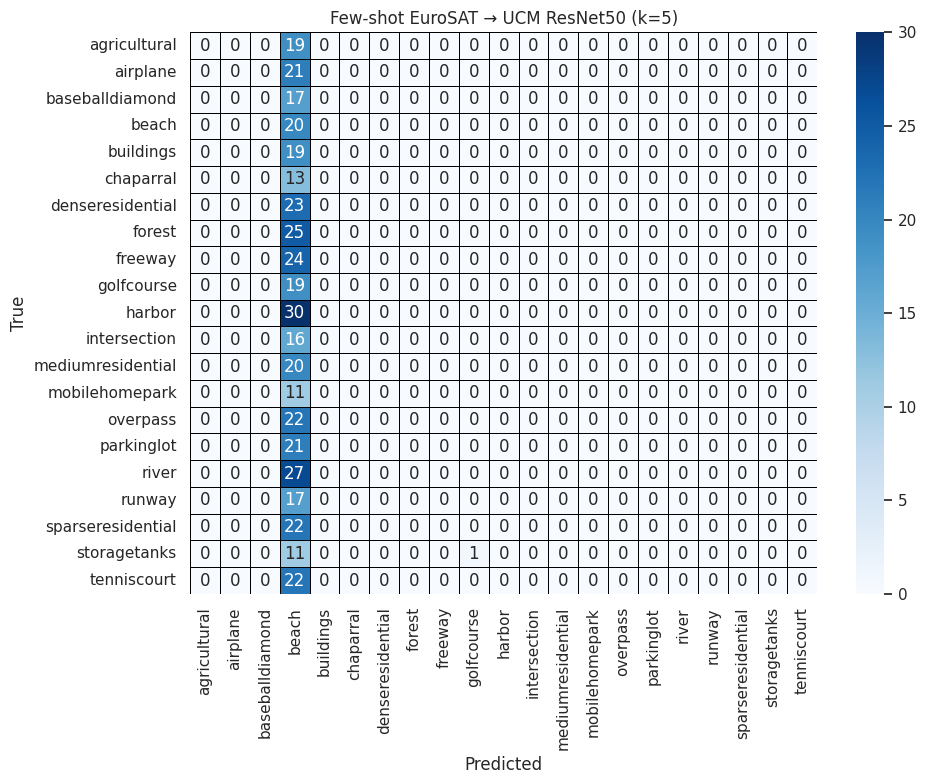

In [20]:
show_cm(cm_dict[5], class_names_ucm, "Few-shot EuroSAT → UCM ResNet50 (k=5)")

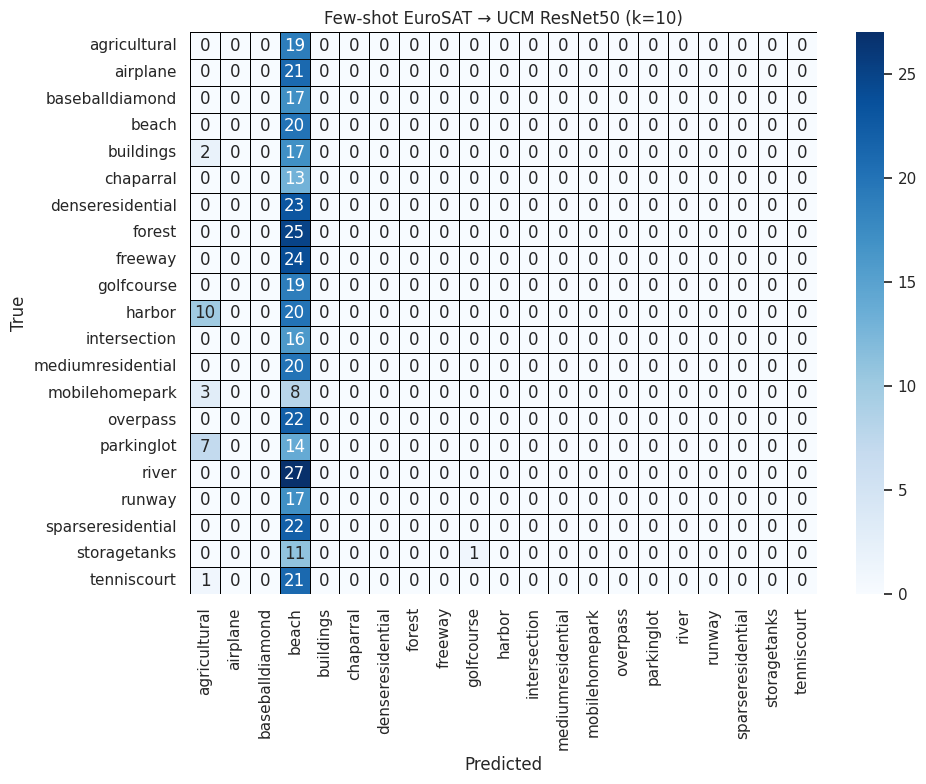

In [21]:
show_cm(cm_dict[10], class_names_ucm, "Few-shot EuroSAT → UCM ResNet50 (k=10)")

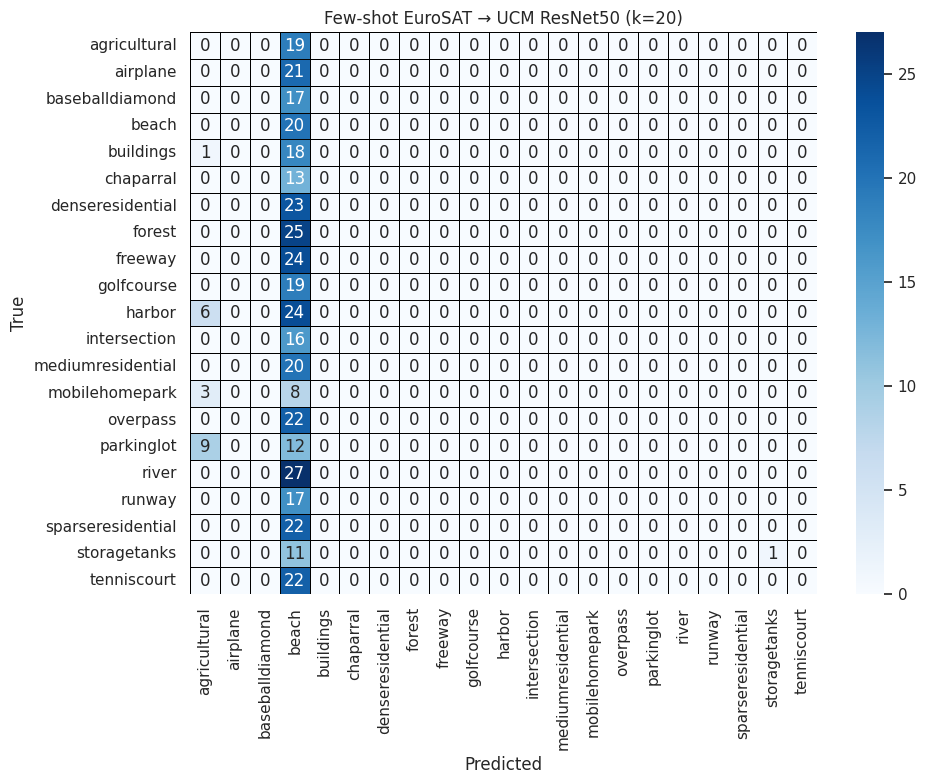

In [22]:
show_cm(cm_dict[20], class_names_ucm, "Few-shot EuroSAT → UCM ResNet50 (k=20)")